In [1]:
from datasets import load_dataset, Features, Value, Sequence, Array2D
import torchvision.transforms.v2 as TV
from torchvision.transforms.functional import crop
import torchaudio.transforms as TA
from torchaudio.functional import resample
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

/home/elia-reppchen/miniconda3/envs/ASP/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Hyperparameters

In [ ]:
# General hyperparameters
SHORTEST_DURATION = 5 # Minimum audio duration in seconds

# Audio hyperparameters
TARGET_SAMPLE_RATE = 16000 # Input sample rate in Hz
N_FFT = 400
HOP_LEN = 160
N_MELS = 80

# Vision hyperparameters
TIMESTEPS = 400 # Crop size for temporal dimension of log-mel spectograms
DBFS_MIN = -100 # Min volume
DBFS_MAX = 40 # Max volume
MEAN = 0.569 # VoxCeleb2 mean
STD = 0.110 # VoxCeleb2 std


input_duration = TIMESTEPS * HOP_LEN / TARGET_SAMPLE_RATE
print("Duration of log-mel spectograms (input): ", input_duration, " seconds")

if input_duration > SHORTEST_DURATION:
    print("WARNING: Training might crash as some samples could have shorter duration than input crop size.")


Duration of log-mel spectograms (input):  4.0  seconds


### Load and clean data

In [3]:
# Load dataset with streaming (only train split available)
dataset = load_dataset("acul3/voxceleb2", split="train", streaming=True)
dataset_features = dataset.features

In [ ]:
# 99.3% english (filter outliers)
dataset = dataset.filter(lambda example: example["language"] == "en")

# Only require audio and speaker ID
dataset = dataset.remove_columns(["transcription", "language", "gender"])
features = dataset.features

# 99.3% audio samples shorter than 33.2s (filter outliers)
def get_duration(example):
    audio = example["audio_path"]
    samples = audio.get_all_samples()
    return samples.duration_seconds
dataset = dataset.filter(lambda example: get_duration(example) < 33.2)

# Also filter out audio samples shorter than SHORTEST_DURATION
dataset = dataset.filter(lambda example: get_duration(example) > SHORTEST_DURATION)

### Transform data

In [5]:
# Audio transforms
audio_transforms = TV.Compose([
    TA.MelSpectrogram(sample_rate=TARGET_SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LEN, n_mels=N_MELS),
    TA.AmplitudeToDB(),
    ])

def preprocess_audio(example):
    audio = example["audio_path"]
    samples = audio.get_all_samples()

    waveform = resample(waveform=samples.data, orig_freq=samples.sample_rate, new_freq=TARGET_SAMPLE_RATE)
    log_mel = audio_transforms(waveform)
    
    example["log_mel"] = log_mel.squeeze(0)
    return example

    
new_features = Features({
    "log_mel": Sequence(Sequence(Value("float32")))
})
features = Features({**features, **new_features})

dataset = dataset.map(preprocess_audio, features=features)
audio_samples = dataset.take(1000)

In [6]:
# Vision transforms
vision_transforms = TV.Compose([
    TV.Resize((224,224)), # ImageNet size
    TV.Normalize(mean=[MEAN, MEAN, MEAN], std=[STD, STD, STD]) # Since images are out of distribution, use approximate dataset statistics

])

def preprocess_vision(example):
    log_mel = example["log_mel"].unsqueeze(0)
    _, h, w = log_mel.shape

    # No center crop like ImageNet, but random crop along temporal dimension of constant length
    left = torch.randint(low=0, high=w-TIMESTEPS, size=(1,)).item()
    log_mel = crop(img=log_mel, top=0, left=left, height=h, width=TIMESTEPS)

    # Scale to [0, 1] like for ImageNet
    log_mel = torch.clamp(input=log_mel, min=DBFS_MIN, max=DBFS_MAX) # Reasonable range
    log_mel = (log_mel - DBFS_MIN) / (DBFS_MAX - DBFS_MIN)#

    # 3 channels like ImageNet data
    log_mel = log_mel.repeat(3, 1, 1)

    log_mel = vision_transforms(log_mel)

    example["log_mel"] = log_mel
    return example

# Now all log mel spectograms have same shape
new_features = Features({
    "log_mel": Array2D(shape=(3, 224,224), dtype="float32")
})
features = Features({**features, **new_features}) # Overwrites old value

dataset = dataset.map(preprocess_vision, features=features)
vision_samples = dataset.take(1000)

### Some data exploration to determine hyperparameters

100%|██████████| 1000/1000 [01:00<00:00, 16.52it/s]


Shape:  torch.Size([80, 647])
Num Positive:  7557156
Min dB:  -100.0
Max dB:  39.13336944580078


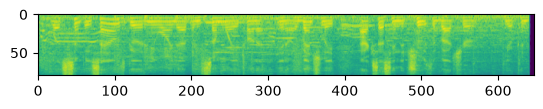

In [7]:
global_max = float('-inf')
global_min = float('inf')
num_positive = 0

for sample in tqdm(audio_samples, total=1000):
    log_mel = sample["log_mel"]
    
    local_max = log_mel.max().item()
    local_min = log_mel.min().item()

    num_positive += torch.sum(log_mel > 0.0).item()
    
    if local_max > global_max:
        global_max = local_max
    if local_min < global_min:
        global_min = local_min


audio_sample = next(iter(audio_samples))
plt.imshow(audio_sample["log_mel"])
print("Shape: ", audio_sample["log_mel"].shape)

print("Num Positive: ", num_positive)
print("Min dB: ", global_min)
print("Max dB: ", global_max)

100%|██████████| 1000/1000 [00:52<00:00, 19.12it/s]


Shape:  torch.Size([3, 224, 224])
Global Mean:  0.0026910807259264095
Max Standard Deviation:  0.9954396822248369


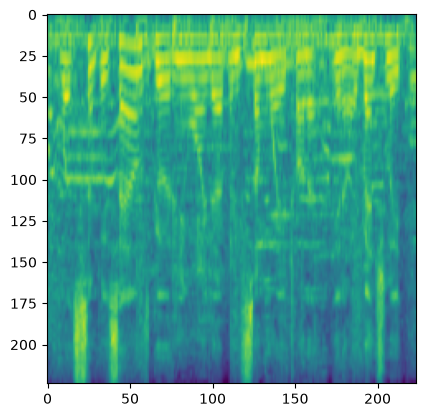

In [8]:
count = 0
running_mean = 0.0
running_M2 = 0.0 # Sum of squares (M2)

# Welford's algorithm
for sample in tqdm(vision_samples, total=1000):
    log_mel = sample["log_mel"][0].view(-1)
    
    n_new = log_mel.numel()
    new_mean = log_mel.mean().item()
    new_var = log_mel.var(unbiased=False).item()
    
    if count == 0:
        count = n_new
        running_mean = new_mean
        running_M2 = new_var * n_new
    else:
        old_count = count
        count += n_new
        
        delta = new_mean - running_mean
        running_mean += delta * n_new / count
        running_M2 += new_var * n_new + (delta ** 2) * old_count * n_new / count

global_mean = running_mean
global_variance = running_M2 / count
global_std = global_variance ** 0.5

vision_sample = next(iter(vision_samples))
plt.imshow(vision_sample["log_mel"][0])
print("Shape: ", vision_sample["log_mel"].shape)

print("Global Mean: ", global_mean)
print("Max Standard Deviation: ", global_std)